<a href="https://colab.research.google.com/github/Sanggoldsilver/Colab_archive/blob/main/%EC%BF%BC%EB%93%9C%EB%9E%AB_%EC%B9%B4%EC%9D%B4%EC%A0%9C%EA%B3%B1_%EC%B5%9C%EA%B7%BC%EB%A6%B0_%ED%85%8C%EC%8A%A4%ED%8A%B8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 공간 점 패턴 분석 (Spatial Point Pattern Analysis)

이 노트북은 언급하신 두 가지 분석 방법을 구현합니다:
1. **쿼드랫 분석 (Quadrat Analysis)**: 격자망 내의 점 개수를 포아송 분포와 비교하여 카이제곱 검정으로 분석합니다.
2. **최근린 분석 (Nearest Neighbor Analysis, NNA)**: 최근린 비율(NNR)을 계산하여 분포가 군집형, 무작위형, 또는 분산형인지 판정합니다.

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 2 not upgraded.
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 12 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no such directory
/root/.fonts: skipping, no such directory
/usr/share/fonts/truetype: skipping, looped directory detected
/usr/share/fonts/truetype/humor-sans: skipping, looped directory detected
/usr/share/fonts/truetype/liberation: skipping, looped directory detected
/usr/share/fonts/truetype/n

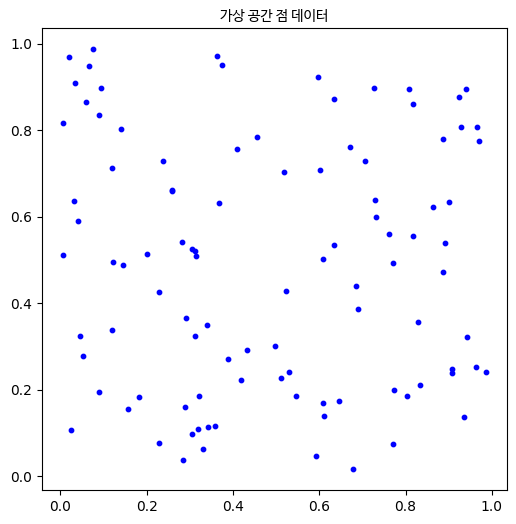

In [ ]:
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from scipy.stats import chi2
from sklearn.neighbors import NearestNeighbors

# 설치된 나눔 폰트의 경로를 찾아 직접 설정
font_path = '/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf'
font_prop = fm.FontProperties(fname=font_path)
plt.rc('font', family='NanumBarunGothic')
plt.rcParams['axes.unicode_minus'] = False

# 가상 데이터 생성: 무작위 분포 (포아송 점 프로세스)
np.random.seed(42)
n_points = 100
points = np.random.rand(n_points, 2)  # 1x1 단위 정사각형 내의 점들

plt.figure(figsize=(6,6))
plt.scatter(points[:,0], points[:,1], s=10, c='blue')
plt.title('가상 공간 점 데이터', fontproperties=font_prop)
plt.show()

### 데이터 기초 통계량 확인
생성된 데이터의 X, Y 좌표 범위를 확인하여 1x1 공간에 잘 분포되어 있는지 검토합니다.

In [ ]:
import pandas as pd

df_points = pd.DataFrame(points, columns=['X', 'Y'])
display(df_points.describe())

,X,Y
count,100.000000,100.000000
mean,0.481044,0.486969
std,0.305490,0.285409
min,0.005522,0.016588
25%,0.235428,0.225399
50%,0.444008,0.498928
75%,0.763331,0.735643
max,0.985650,0.986887


## 1. 쿼드랫 분석
1x1 영역을 5x5 격자(총 25개 쿼드랫)로 나누어 분석합니다.

In [ ]:
def quadrat_analysis(points, nx=5, ny=5):
    counts, xedges, yedges = np.histogram2d(points[:,0], points[:,1], bins=[nx, ny])
    observed = counts.flatten()
    n_quadrats = nx * ny
    mean_points = len(points) / n_quadrats

    # 카이제곱 통계량: sum((관측값 - 기댓값)^2 / 기댓값)
    chi_sq_stat = np.sum((observed - mean_points)**2 / mean_points)
    p_val = 1 - chi2.cdf(chi_sq_stat, df=n_quadrats - 1)

    print(f'총 쿼드랫 수: {n_quadrats}')
    print(f'쿼드랫당 평균 점 개수 (기댓값): {mean_points:.2f}')
    print(f'카이제곱 통계량: {chi_sq_stat:.2f}')
    print(f'P-value: {p_val:.4f}')

    if p_val < 0.05:
        print("결과: 무작위 분포에서 유의미하게 벗어남 (비균등 분포)")
    else:
        print("결과: 무작위 분포에서 유의미한 차이 없음 (균등/무작위 분포)")

quadrat_analysis(points)

총 쿼드랫 수: 25
쿼드랫당 평균 점 개수 (기댓값): 4.00
카이제곱 통계량: 32.00
P-value: 0.1270
결과: 무작위 분포에서 유의미한 차이 없음 (균등/무작위 분포)


### 쿼드랫 시각화
실제로 격자망을 그려서 점들이 어떻게 나뉘어 들어갔는지 시각적으로 확인합니다.

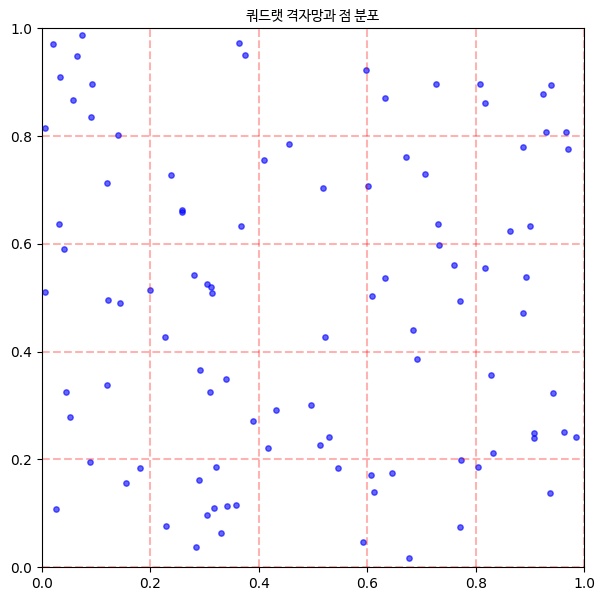

In [ ]:
plt.figure(figsize=(7,7))
plt.scatter(points[:,0], points[:,1], s=15, c='blue', alpha=0.6)

# 5x5 격자 그리기
for i in np.linspace(0, 1, 6):
    plt.axvline(i, color='red', linestyle='--', alpha=0.3)
    plt.axhline(i, color='red', linestyle='--', alpha=0.3)

plt.title('쿼드랫 격자망과 점 분포', fontproperties=font_prop)
plt.xlim(0,1)
plt.ylim(0,1)
plt.show()

## 2. 최근린 분석 (NNA)
다음 기준에 따라 NNR을 계산합니다:
- $NNR \approx 0$: 군집 분포형 (Clustered)
- $NNR \approx 1$: 무작위형 (Random)
- $NNR \approx 2.15$: 분산형 (Dispersed)

In [ ]:
def nearest_neighbor_analysis(points, area=1.0):
    n = len(points)
    nbrs = NearestNeighbors(n_neighbors=2).fit(points)
    distances, indices = nbrs.kneighbors(points)

    # 첫 번째 열은 자기 자신과의 거리(0), 두 번째 열이 최근린 거리
    obs_mean_dist = np.mean(distances[:, 1])

    # 무작위 분포 시 기대되는 평균 거리: 0.5 / sqrt(n/Area)
    exp_mean_dist = 0.5 / np.sqrt(n / area)

    nnr = obs_mean_dist / exp_mean_dist

    print(f'관측된 평균 거리: {obs_mean_dist:.4f}')
    print(f'기대된 평균 거리: {exp_mean_dist:.4f}')
    print(f'최근린 비율 (NNR): {nnr:.4f}')

    if nnr < 1: print("패턴: 군집형 (Clustered)")
    elif nnr > 1: print("패턴: 분산형 (Dispersed)")
    else: print("패턴: 무작위형 (Random)")

nearest_neighbor_analysis(points)

관측된 평균 거리: 0.0487
기대된 평균 거리: 0.0500
최근린 비율 (NNR): 0.9747
패턴: 군집형 (Clustered)


## 3. 커널 밀도 추정 (Kernel Density Estimation)
점들의 국지적 밀도를 계산하여 핫스팟(Hotspot)을 찾아내는 시각화 방법입니다.

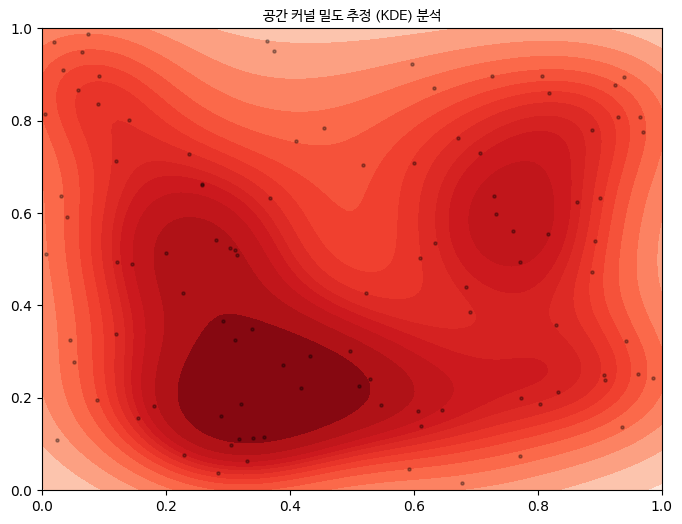

In [ ]:
import seaborn as sns

plt.figure(figsize=(8,6))
sns.kdeplot(x=points[:,0], y=points[:,1], cmap="Reds", fill=True, thresh=0, levels=15)
plt.scatter(points[:,0], points[:,1], s=5, c='black', alpha=0.3)
plt.title('공간 커널 밀도 추정 (KDE) 분석', fontproperties=font_prop)
plt.xlim(0,1)
plt.ylim(0,1)
plt.show()